# 🧠 RL & Reasoning Models

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-22

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/03-advanced-llms/4-rl-and-reasoning/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/03-advanced-llms/4-rl-and-reasoning/index.qmd)

In [\[03.3\] Mid- & Post-Training](../3-mid-post-training/index.qmd) you
turned a **base model** into an instruction-follower with supervised
fine-tuning (SFT). SFT is *imitation*: it copies reference completions
token-for-token. But the best answer is often not in your dataset, and
“good” is hard to write down as a single target string. **Reinforcement
learning** takes over here: instead of imitating a fixed answer, we let
the model *generate*, **score** each generation, and push the policy
toward the high-scoring behavior — either what humans **prefer**, or
what a verifier can **prove correct**.

That second idea — reward = a programmatic check — is what powers
today’s **reasoning models** (DeepSeek-R1, o1-style): reward correct
final answers and, remarkably, an explicit chain-of-thought *emerges on
its own*. This lab builds to it via a runnable toy GRPO loop, the
algorithm family (PPO / DPO / GRPO / RLVR), and the `<think>` recipe.

> **Render note**
>
> `trl`, `peft`, and `vllm` are **not** installed in the site build
> environment, and real RL fine-tuning needs a GPU. Every cell that
> touches them is marked `#| eval: false`, so it renders as
> copy-pasteable code without running. The one toy cell that *does* run
> uses only `torch` (CPU) on tiny tensors — flip its `eval` to run it,
> or drop it on the cluster as-is.

## 🧪 ① A toy that really runs

### (a) GRPO / RLVR from scratch, in plain PyTorch

Strip away the language model and GRPO is short. The essence of **Group
Relative Policy Optimization** ([Shao et al. 2024,
arXiv:2402.03300](https://arxiv.org/abs/2402.03300)) is:

1.  For **one prompt**, sample a **group** of $K$ completions from the
    policy.
2.  Score each with a **verifiable reward** — no learned reward model,
    just a checker (RLVR: *RL from Verifiable Rewards*).
3.  Standardize the rewards *within the group* to get an **advantage**:
    better-than- average completions get positive advantage,
    worse-than-average get negative.
4.  Nudge the policy with a **policy gradient** — raise the probability
    of the good completions, lower the probability of the bad ones.

Here the “policy” is a categorical distribution over a handful of
candidate answers to `2 + 3 = ?`. Everything is a tiny tensor, so this
runs on a laptop CPU:

In [1]:
import torch
import torch.nn.functional as F

torch.manual_seed(0)

# --- A toy "policy": a categorical over candidate completions. ---
# In a real LM these would be full token sequences; here each "completion" is
# one candidate final answer to the prompt "2 + 3 = ?".
completions = ["5", "5.0", "six", "23", "cinq"]
logits = torch.zeros(len(completions), requires_grad=True)  # pi_theta(completion)

# --- A VERIFIABLE reward: no learned reward model, just a checker. ---
# +1.0 if exactly correct, +0.1 if it at least parses as a number
# (right *format*, wrong value), else 0.  This is the RLVR idea.
def verify(text: str) -> float:
    if text.strip() == "5":
        return 1.0
    try:
        float(text)
        return 0.1
    except ValueError:
        return 0.0

K, lr = 8, 0.5  # group size, learning rate

for step in range(60):
    dist = torch.distributions.Categorical(logits=logits)
    idx = dist.sample((K,))                                    # K completions
    r = torch.tensor([verify(completions[i]) for i in idx])    # verifiable rewards

    # Group-relative advantage: standardize rewards WITHIN the group.
    adv = (r - r.mean()) / (r.std() + 1e-8)

    # Policy-gradient objective:  maximize  E[ advantage * log pi(sample) ]
    loss = -(adv * dist.log_prob(idx)).mean()

    logits.grad = None
    loss.backward()
    with torch.no_grad():
        logits -= lr * logits.grad                            # ascend the reward

probs = F.softmax(logits, dim=-1).detach()
for c, p in zip(completions, probs):
    print(f"P({c!r:>7}) = {p:.3f}")

P(    '5') = 0.991
P(  '5.0') = 0.003
P(  'six') = 0.002
P(   '23') = 0.002
P( 'cinq') = 0.002

The policy starts uniform and, using **only** the verifier’s signal,
concentrates its probability mass on `"5"`. A few things worth noticing,
because they carry over exactly to the real thing:

- **No reward model.** `verify()` is a Python function. RLVR replaces a
  learned, fallible reward model with a cheap, exact check.
- **The group is the baseline.** Subtracting `r.mean()` is a
  *variance-reduction* baseline computed from the group itself — that is
  the “group relative” in GRPO, and why it needs **no value network**
  (unlike PPO).
- **Zero-variance groups give zero signal.** If all $K$ samples get the
  same reward, `adv` is all zeros and nothing updates — the model
  already agrees with the group, so there is nothing to learn from it.

### (b) The same idea in TRL (display-only)

In practice the policy is an LLM and TRL’s `GRPOTrainer` runs the loop
above over real token sequences. You supply the model, a dataset of
**prompts**, and a **list of reward functions** — each is just a Python
callable returning a score per completion:

In [2]:
from datasets import load_dataset
from trl import GRPOConfig, GRPOTrainer

# Prompts only — GRPO generates the completions itself, then scores them.
train_dataset = load_dataset("trl-lib/tldr", split="train")

# Verifiable rewards: plain Python. Return one float per completion.
def reward_len(completions, **kwargs):
    # Prefer completions close to 50 tokens (a formatting-style reward).
    return [-abs(50 - len(c.split())) for c in completions]

def reward_no_repeat(completions, **kwargs):
    # Penalize degenerate repetition.
    return [0.0 if len(set(c.split())) > 5 else -5.0 for c in completions]

config = GRPOConfig(
    output_dir="grpo-out",
    num_generations=8,            # K: the group size per prompt
    per_device_train_batch_size=8,
    learning_rate=1e-6,           # RL fine-tuning uses a TINY LR
    max_completion_length=256,
    bf16=True,
    # use_vllm=True,              # fast generation backend at scale
)

trainer = GRPOTrainer(
    model="Qwen/Qwen2.5-0.5B-Instruct",
    reward_funcs=[reward_len, reward_no_repeat],  # <- list of verifiers
    args=config,
    train_dataset=train_dataset,
)
trainer.train()

**DPO** is the other workhorse and needs *no* sampling loop at all.
Instead of a reward, it consumes **preference pairs** — a prompt with a
`chosen` and a `rejected` completion — and directly optimizes the policy
to prefer `chosen` ([Rafailov et al. 2023,
arXiv:2305.18290](https://arxiv.org/abs/2305.18290)):

In [3]:
from datasets import load_dataset
from trl import DPOConfig, DPOTrainer

# Each row: {"prompt", "chosen", "rejected"} — human (or AI) preference pairs.
dataset = load_dataset("trl-lib/ultrafeedback_binarized", split="train")

config = DPOConfig(
    output_dir="dpo-out",
    beta=0.1,                    # KL strength: how far to drift from the ref model
    learning_rate=5e-7,
    per_device_train_batch_size=4,
    bf16=True,
)

trainer = DPOTrainer(
    model="Qwen/Qwen2.5-0.5B-Instruct",  # the reference model is a frozen copy
    args=config,
    train_dataset=dataset,
)
trainer.train()

## 🏭 ② The real thing

*(display-only — algorithm comparison + the reasoning-model recipe)*

All four methods answer the same question — *“how do we push the policy
toward better outputs?”* — but differ in **what supervision they need**
and **what extra machinery they carry**.

| Method | Needs reward model? | Needs preference pairs? | Needs verifier? | Needs value network? | Notes |
|:------|:-------------:|:----------------:|:----------:|:--------------:|:----|
| **PPO** | ✅ learned RM | to *train* the RM | ❌ | ✅ critic | Classic RLHF ([InstructGPT](https://arxiv.org/abs/2203.02155)); most moving parts (policy + RM + critic + ref). |
| **DPO** | ❌ | ✅ chosen/rejected | ❌ | ❌ | No sampling, no RM. Directly optimizes preferences vs. a frozen ref. Stable & cheap. |
| **GRPO** | ✅ *or* verifier | ❌ (uses rewards) | ✅ if RLVR | ❌ (group baseline) | Drops PPO’s critic; baseline = group mean. Online sampling. |
| **RLVR** | ❌ | ❌ | ✅ **required** | ❌ | GRPO/PPO where the reward *is* a programmatic verifier (math/code/format). |

Table 1: What each RL method needs. RLVR is not a separate optimizer —
it is GRPO/PPO with a **verifier** in place of a learned reward model.

**PPO** ([Schulman et al. 2017](https://arxiv.org/abs/1707.06347); as
RLHF in [Ouyang et al. 2022,
arXiv:2203.02155](https://arxiv.org/abs/2203.02155)) is the original
recipe: train a **reward model** on human preferences, then optimize the
policy against it with PPO, using a **value network** (critic) to
estimate the baseline and a KL penalty to a frozen reference. Powerful,
but four models in memory and a reward model that can be *hacked*.

**GRPO** removes the critic: instead of learning a value function, it
estimates the baseline empirically from a **group** of $K$ samples for
the same prompt — exactly the standardization from the toy. For each
completion $i$ in a group with rewards $\mathbf{r} = (r_1, \dots, r_K)$,
the **group-relative advantage** is

$$\hat{A}_i = \frac{r_i - \operatorname{mean}(\mathbf{r})}{\operatorname{std}(\mathbf{r})}$$

**RLVR** removes the *reward model*. The insight ([Lambert et al. 2024,
Tülu 3, arXiv:2411.15124](https://arxiv.org/abs/2411.15124)) is that for
many tasks we don’t need to *learn* what “good” means — we can **check**
it:

- **Math** — parse the final answer and compare to ground truth (or run
  it through a symbolic checker).
- **Code** — run the unit tests; reward = fraction passing.
- **Format** — regex/parse: did the output obey the required structure?

A verifier is cheaper, exact, and **can’t be reward-hacked** the way a
learned RM can. That makes it the engine of the reasoning-model recipe:

<figure id="fig-reasoning-recipe">
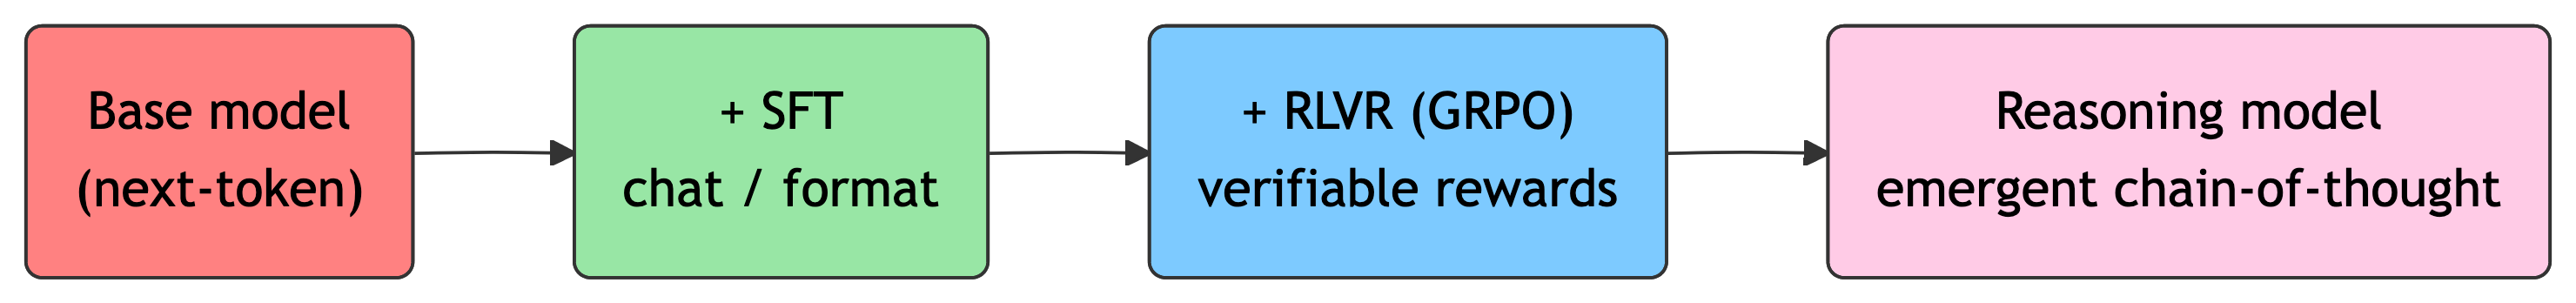
<figcaption>Figure 1: The reasoning-model recipe: <strong>base → SFT →
RLVR</strong>. DeepSeek-R1 showed that RLVR on top of a capable base
model makes long chain-of-thought reasoning <strong>emerge</strong>,
rewarded only by final-answer correctness — no step-by-step supervision
required.</figcaption>
</figure>

> **🔬 At frontier scale…**
>
> DeepSeek-R1 ([arXiv:2501.12948](https://arxiv.org/abs/2501.12948))
> pushes RLVR to its limit. Their **R1-Zero** run applies GRPO *directly
> to the base model* with purely verifiable rewards — no SFT warm-up —
> and watches reasoning behaviors (self-checking, backtracking, and
> steadily **longer** `<think>` traces) appear on their own as accuracy
> climbs. The full **R1** adds a small SFT “cold start” for readability,
> then large-scale GRPO across many nodes with a fast generation backend
> (e.g. vLLM) feeding the training ranks.
>
> The distributed machinery underneath is exactly what you already know
> from [\[01.4\] Distributed
> Training](../../01-neural-networks/4-distributed-training/index.qmd):
> the policy is sharded with ZeRO/FSDP, generation is parallelized
> across ranks, and rewards are gathered with the same collectives. RL
> just adds a **generate → verify → update** loop around the training
> step. The API below is the same one you saw in §①b — only the model
> size, the verifier, and the node count change.

## 🤖 ③ Build an agentic reasoning model

The trick that makes a model *reason* is a **format contract**: force
the model to “think out loud” inside `<think>...</think>` tags
**before** committing to a final answer. During RLVR we only score what
comes **after** `</think>`, so the model is free to use the scratchpad
however it likes — and because longer, more careful reasoning
empirically leads to more correct final answers, the reasoning behavior
is *reinforced* even though we never reward the reasoning directly.

**1. A system/format prompt** that demands the structure:

In [4]:
SYSTEM_PROMPT = (
    "You are a careful problem-solver. Work through the problem step by step "
    "inside <think> </think> tags, then give ONLY the final answer inside "
    "<answer> </answer> tags.\n"
    "Format: <think> your reasoning </think><answer> final answer </answer>"
)

def make_prompt(question: str) -> list[dict]:
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

**2. Reward functions** that parse the region after `</think>` and check
it — one verifier for **correctness**, one for **format**. This list is
exactly what you’d hand to `GRPOTrainer(reward_funcs=[...])`:

In [5]:
import re

def extract_answer(text: str) -> str | None:
    m = re.search(r"<answer>(.*?)</answer>", text, re.DOTALL)
    return m.group(1).strip() if m else None

def reward_correct(completions, answer, **kwargs):
    """RLVR: +1 if the parsed final answer matches ground truth, else 0."""
    out = []
    for completion, gold in zip(completions, answer):
        pred = extract_answer(completion)
        out.append(1.0 if pred is not None and pred == str(gold) else 0.0)
    return out

def reward_format(completions, **kwargs):
    """Shape the output: small bonus for obeying the <think>/<answer> contract."""
    pattern = r"<think>.*?</think>\s*<answer>.*?</answer>"
    return [0.2 if re.search(pattern, c, re.DOTALL) else 0.0 for c in completions]

**3. A realistic rollout.** Given the prompt
`"If a train travels 60 km in 1.5 hours, what is its average speed in km/h?"`,
a mid-training policy might sample a group like this (only two of $K$
shown):

``` text
# completion 1  -> reward_correct = 1.0, reward_format = 0.2
<think>
Average speed = distance / time. Distance = 60 km, time = 1.5 h.
60 / 1.5 = 40. Units are km/h, which matches the question.
</think>
<answer>40</answer>

# completion 2  -> reward_correct = 0.0, reward_format = 0.2
<think>
Speed is distance times time, so 60 * 1.5 = 90.
</think>
<answer>90</answer>
```

Both obey the format (`+0.2`), but only the first is correct (`+1.0`).
Summed rewards are `1.2` vs `0.2`; after group standardization the
correct rollout gets a **positive** advantage and the wrong one
**negative** — so GRPO raises the probability of the reasoning path that
led to `40` and lowers the other. Repeat over thousands of prompts and
correct-answer-producing reasoning is what survives.

**4. See it happen.** The two reward functions above are
`#| eval: false` (they’d be handed to `GRPOTrainer`), but they’re plain
Python — so we can run them *now* on a sampled group and feed the result
through the **same** `(r - mean) / std` line from the toy in §①a. This
turns the prose above into numbers, on a laptop CPU:

In [6]:
import re
import torch

# The §③ verifiers — real code, just executed here instead of inside GRPOTrainer.
def extract_answer(text):
    m = re.search(r"<answer>(.*?)</answer>", text, re.DOTALL)
    return m.group(1).strip() if m else None

def reward_correct(completions, answer):
    return [1.0 if extract_answer(c) == str(g) else 0.0
            for c, g in zip(completions, answer)]

def reward_format(completions):
    pattern = r"<think>.*?</think>\s*<answer>.*?</answer>"
    return [0.2 if re.search(pattern, c, re.DOTALL) else 0.0 for c in completions]

# One prompt (gold answer "40"); a group of K=4 sampled rollouts.
group = [
    "<think>60 / 1.5 = 40, units km/h.</think><answer>40</answer>",  # right + formatted
    "<think>60 * 1.5 = 90.</think><answer>90</answer>",              # wrong + formatted
    "<think>60/1.5 = 40.</think><answer>40</answer>",                # right + formatted
    "The average speed is 40 km/h.",                                 # right value, NO tags
]
gold = ["40"] * len(group)

# Total reward = sum of the verifiers -> GRPO group-relative advantage.
r = torch.tensor(reward_correct(group, gold)) + torch.tensor(reward_format(group))
adv = (r - r.mean()) / (r.std() + 1e-8)        # identical to §①a

for i, (tot, a) in enumerate(zip(r.tolist(), adv.tolist())):
    print(f"rollout {i}:  reward = {tot:>4.1f}   advantage = {a:+.2f}")

rollout 0:  reward =  1.2   advantage = +0.86
rollout 1:  reward =  0.2   advantage = -0.70
rollout 2:  reward =  1.2   advantage = +0.86
rollout 3:  reward =  0.0   advantage = -1.02

There is the `1.2` vs `0.2` from the text — now computed — and the group
split into **positive** and **negative** advantage. Notice rollout 3 got
the right *value* but skipped the tags: `reward_correct` can’t parse it,
so it scores the **worst** of the group. That is precisely why the
format contract is rewarded — no parseable answer, no credit.

> **Exercise — zero-variance groups**
>
> The §①a toy noted that if every sample in a group gets the **same**
> reward, the advantage is all zeros and nothing updates. Rebuild
> `group` so all four rollouts are **correct *and* formatted**,
> recompute `adv`, and confirm you get zeros — the policy already agrees
> with the group, so there’s nothing to learn from it.
>
> > **💡 Solution**
> >
> > ``` python
> > group = ["<think>60/1.5 = 40.</think><answer>40</answer>"] * 4
> > gold = ["40"] * len(group)
> > r = torch.tensor(reward_correct(group, gold)) + torch.tensor(reward_format(group))
> > adv = (r - r.mean()) / (r.std() + 1e-8)
> > print("advantages:", [round(a, 2) for a in adv.tolist()])  # all 0.0 -> no gradient
> > ```
> >
> >     advantages: [0.0, 0.0, 0.0, 0.0]

<figure id="fig-rlvr-loop">
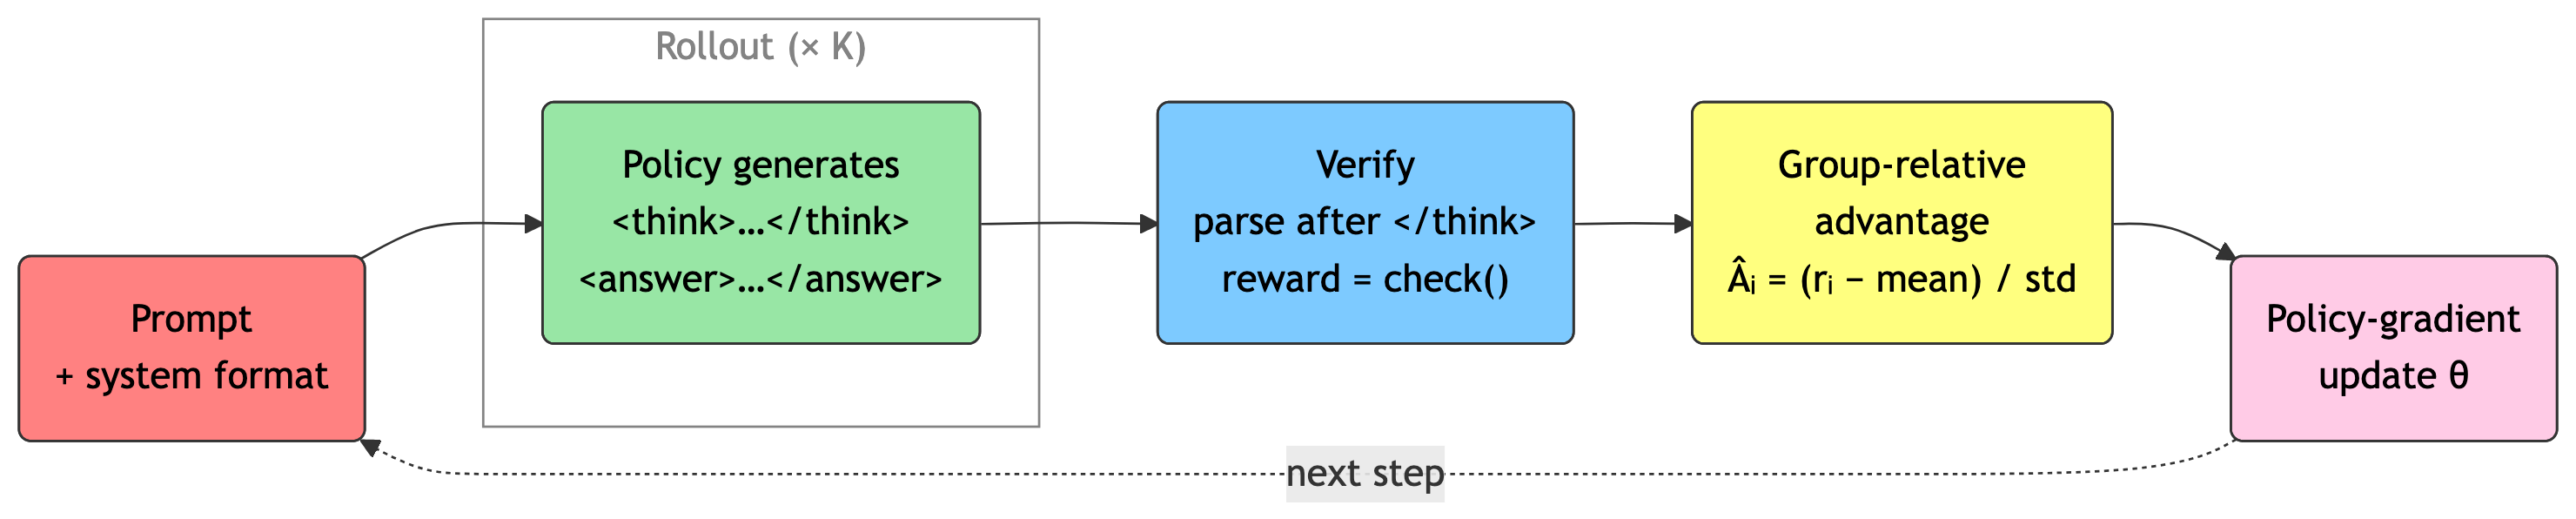
<figcaption>Figure 2: The RLVR reasoning loop. <strong>rollout → verify
→ advantage → update</strong>, repeated. The only human input is the
verifier; the reasoning inside <code>&lt;think&gt;</code> is discovered
by the policy.</figcaption>
</figure>

### 🚀 Scale it up

On the cluster, run GRPO as a plain Python module and let `ezpz` handle
the launch — it auto-detects the scheduler (PBS → `mpiexec`, SLURM →
`srun`) and wires up the distributed environment for you.

1.  Set up the environment and install the RL stack:

    ``` bash
    source <(curl -fsSL https://bit.ly/ezpz-utils) && ezpz_setup .venv
    uv pip install git+https://github.com/saforem2/ezpz
    uv pip install "trl>=0.14" "peft>=0.13" "datasets" "accelerate" "vllm"
    ```

2.  Confirm the distributed setup works:

    ``` bash
    ezpz test
    ```

3.  Launch multi-GPU / multi-node GRPO with verifiable rewards.
    `ezpz launch` runs the command across every rank of your allocation:

    ``` bash
    ezpz launch python3 -m trl.scripts.grpo \
        --model_name_or_path Qwen/Qwen2.5-0.5B-Instruct \
        --dataset_name trl-lib/tldr \
        --num_generations 8 \
        --learning_rate 1e-6 \
        --per_device_train_batch_size 8 \
        --max_completion_length 256 \
        --bf16 \
        --use_peft --lora_r 16 --lora_alpha 32 \
        --output_dir grpo-out
    ```

4.  For long runs, add fault tolerance (spare nodes + automatic
    failover):

    ``` bash
    ezpz launch --auto-retry --spare-nodes auto \
        python3 -m trl.scripts.grpo --model_name_or_path Qwen/Qwen2.5-0.5B-Instruct ...
    ```

## 🎒 Homework

Train (or prompt-then-train) a small model to use the `<think>` pattern
on a **toy math task** and reward **correct final answers** with RLVR,
then submit *proof* that the reward went up over training.

Your submission should include:

1.  The **system/format prompt** enforcing
    `<think>…</think><answer>…</answer>`, and your **reward
    function(s)** (a correctness verifier, optionally a format reward).
2.  A tiny **dataset of prompts** with ground-truth answers
    (e.g. 100–500 grade-school arithmetic or
    [GSM8K](https://huggingface.co/datasets/openai/gsm8k)-style
    problems).
3.  A **reward-vs-step** curve (or the logged numbers) showing the mean
    reward *increasing* as GRPO trains — this is your proof-of-run.

Where *proof* can be any of:

- The contents printed to your terminal during the run (per-step
  reward).
- A path to a logfile from a run on the ALCF filesystems.
- A screenshot of the reward curve or a sample `<think>` rollout before
  vs. after.
- A url to a [W&B Run](https://wandb.ai) or W&B Report.

> **Hint**
>
> Start from `Qwen/Qwen2.5-0.5B-Instruct` (it already speaks a chat
> template), `GRPOTrainer` with `num_generations=8`, and the two reward
> functions from §③. Keep `max_completion_length` small and use a
> handful of arithmetic prompts so a step takes seconds. Log the mean of
> `reward_correct` each step and watch it climb.

## 📚 References

- Ouyang et al., *Training language models to follow instructions with
  human feedback* (InstructGPT / PPO-RLHF) —
  [arXiv:2203.02155](https://arxiv.org/abs/2203.02155)
- Rafailov et al., *Direct Preference Optimization* (DPO) —
  [arXiv:2305.18290](https://arxiv.org/abs/2305.18290)
- Shao et al., *DeepSeekMath* (introduces GRPO) —
  [arXiv:2402.03300](https://arxiv.org/abs/2402.03300)
- Lambert et al., *Tülu 3: Pushing Frontiers in Open Language Model
  Post-Training* (RLVR) —
  [arXiv:2411.15124](https://arxiv.org/abs/2411.15124)
- DeepSeek-AI, *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs
  via RL* — [arXiv:2501.12948](https://arxiv.org/abs/2501.12948)
- HuggingFace TRL — [GRPO
  Trainer](https://huggingface.co/docs/trl/grpo_trainer) · [DPO
  Trainer](https://huggingface.co/docs/trl/dpo_trainer) · [PPO
  Trainer](https://huggingface.co/docs/trl/ppo_trainer)
- Previous: [\[03.3\] Mid- &
  Post-Training](../3-mid-post-training/index.qmd) — CPT + SFT with
  TRL/PEFT.

Last updated: 2026-07-27 10:33:01